# TẦNG 3 = GOM LÔ + VÙNG KÝ (3b)
### Hệ thống kiểm tra chứng từ giao nhận KIDO

Dự án giữ **4 notebook theo tầng** (T1, T2, T3, T4). Notebook này là **Tầng 3**, gồm 2 phần chạy theo thứ tự:

| Phần | Nội dung | Phạm vi | Module lõi (chỉ import) |
|---|---|---|---|
| **A — Gom lô** | ghép đa trang → lô chuyến xe → hồ sơ đơn hàng → đối soát chéo → checklist quy chuẩn; sinh **manifest bàn giao Tầng 4** | **toàn bộ** ảnh / chứng từ (gom lô cần mọi chứng từ) | `tools/stage3_resolver.py` (`load_stage3_inputs` / `run_stage3_pipeline` / `build_manifest_data` — cùng hàm với lệnh chính thức `tools/stage3_resolver.py --out`) |
| **B — Vùng ký (3b)** | dò vùng ký động theo biểu mẫu, đầu vào hình học cho Tầng 4 ver2 | chỉ `LOADING_PLAN` | `tools/stage3b_zone_resolver.py`, `tools/lp_production_path.py` |

**Nguyên tắc:** mọi con số in ra đều **đo trong cell** hoặc **đọc từ artifact** trên đĩa; markdown không chứa số liệu tự chấm. Không đoán: không đủ bằng chứng thì **cách ly / ABSTAIN tường minh**.

**Tham số (Phần A):** `OUT_PATH` — nơi ghi manifest Tầng 3. Mặc định `output/stage3_out/stage3_batched_manifest.json` (manifest chính thức); ghi đè bằng biến môi trường `KIDO_T3_OUT_PATH` khi phát triển để không đụng artifact chính thức. Manifest không có timestamp ⇒ chạy lại trên cùng đầu vào phải trùng từng byte.

---
# PHẦN A — GOM LÔ (Tầng 3, `tools/stage3_resolver.py`)

## A.1 Chạy pipeline chính thức + ghi manifest

Đầu vào: `output/stage2_out/stage2_classified_results.json` (Tầng 2), `config/stage3_business_rules.json` (luật), `config/stage3_shipment_reference.json` (**dữ liệu tham chiếu mã chuyến — bản demo suy từ GT**, AGENTS.md 9.12.B), `output/form_catalog.json` (ma trận quy chuẩn). Cell so manifest vừa sinh với manifest chính thức trên đĩa (so JSON; manifest không có trường thời gian).

In [1]:
import os, sys, time, json, hashlib, warnings
from pathlib import Path
from collections import Counter, defaultdict

ROOT = Path(os.getcwd())
if not (ROOT / "tools" / "stage3_resolver.py").exists():
    raise RuntimeError(f"Phai chay notebook tu thu muc goc du an (cwd = {ROOT})")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8")

import pandas as pd
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 200)

from tools.stage3_resolver import (                                  # CHI import, khong sua
    load_stage3_inputs, run_stage3_pipeline, build_manifest_data, write_manifest,
    evaluate_multipage_gt, evaluate_shipment_batches_gt, evaluate_order_dossiers_gt, evaluate_reconciliation_gt,
    OFFICIAL_MANIFEST_PATH, DEFAULT_REFERENCE_PATH, MANIFEST_VERSION,
)

# ----------------------------- THAM SO -----------------------------
OUT_PATH = os.environ.get("KIDO_T3_OUT_PATH", OFFICIAL_MANIFEST_PATH)
REFERENCE_PATH = DEFAULT_REFERENCE_PATH
GT3_PATH = "output/stage3_gt.json"
# -------------------------------------------------------------------

def _md5_bytes(b):
    return hashlib.md5(b).hexdigest()

def json_diff(a, b, path="$", out=None, limit=30):
    out = [] if out is None else out
    if len(out) >= limit:
        return out
    if type(a) != type(b):
        out.append(f"{path}: kieu {type(a).__name__} != {type(b).__name__}")
    elif isinstance(a, dict):
        for k in sorted(set(a) | set(b), key=str):
            if k not in a: out.append(f"{path}.{k}: chi co o ban chinh thuc")
            elif k not in b: out.append(f"{path}.{k}: chi co o ban moi")
            else: json_diff(a[k], b[k], f"{path}.{k}", out, limit)
    elif isinstance(a, list):
        if len(a) != len(b): out.append(f"{path}: do dai {len(a)} != {len(b)}")
        for i, (x, y) in enumerate(zip(a, b)): json_diff(x, y, f"{path}[{i}]", out, limit)
    elif a != b:
        out.append(f"{path}: {a!r} != {b!r}")
    return out

official_p = ROOT / OFFICIAL_MANIFEST_PATH
official_bytes = official_p.read_bytes() if official_p.exists() else None   # doc TRUOC khi (co the) ghi de

t0 = time.time()
recs, cfg, cat = load_stage3_inputs(reference_path=REFERENCE_PATH)
RES = run_stage3_pipeline(recs, cfg, cat)
MANIFEST = build_manifest_data(RES)
t_run = time.time() - t0
out_p = write_manifest(MANIFEST, OUT_PATH)

BATCHES, DOCS = RES["batches"], RES["docs"]
S2_BY_FILE = {r["file_name"]: r for r in RES["stage2_records"]}
GT3 = json.loads((ROOT / GT3_PATH).read_text(encoding="utf-8"))

md = MANIFEST["metadata"]
print(f"Tang 3 v{MANIFEST_VERSION} | {t_run:.2f}s | {md['source_stage2_records']} ban ghi Tang 2 -> "
      f"{md['total_documents']} chung tu -> {md['total_batches']} lo -> {md['total_order_dossiers']} ho so don hang")
print(f"Nhom da trang: {md['multipage_groups_count']} | preset chu ky mapped/unmapped: "
      f"{md['mapped_signatures_count']}/{md['unmapped_signatures_count']} | lo co checklist: {md['checklist_audited_batches']}")
print(f"reference_loaded = {md['reference_loaded']} | reference = {md['reference']}")
print(f"Manifest ghi ra : {out_p}  ({out_p.stat().st_size:,} byte, md5 {_md5_bytes(out_p.read_bytes())})")

if official_bytes is None:
    MANIFEST_SYNC = "KHONG_CO_MANIFEST_CHINH_THUC"
    print(f"[!] Chua co manifest chinh thuc tai {OFFICIAL_MANIFEST_PATH}")
else:
    same_bytes = official_bytes == out_p.read_bytes()        # so FILE vua ghi (write_manifest ghi text-mode)
    diffs = json_diff(json.loads(official_bytes.decode("utf-8")), MANIFEST)
    MANIFEST_SYNC = "IN_SYNC" if not diffs else "OUT_OF_SYNC"
    print(f"So voi manifest chinh thuc {OFFICIAL_MANIFEST_PATH} (md5 truoc khi chay {_md5_bytes(official_bytes)}): "
          f"JSON {'TRUNG' if not diffs else 'LECH'} | byte {'TRUNG' if same_bytes else 'LECH'} => {MANIFEST_SYNC}")
    for d in diffs:
        print("   LECH:", d)
if out_p.resolve() == official_p.resolve():
    print("OUT_PATH = manifest chinh thuc -> da ghi de (noi dung " + ("khong doi)" if MANIFEST_SYNC == "IN_SYNC" else "DA DOI)"))

Tang 3 v3.3.0 | 0.01s | 72 ban ghi Tang 2 -> 65 chung tu -> 28 lo -> 60 ho so don hang
Nhom da trang: 7 | preset chu ky mapped/unmapped: 63/2 | lo co checklist: 28
reference_loaded = True | reference = {'reference_loaded': True, 'reference_path': 'config/stage3_shipment_reference.json', 'reference_status': 'DEMO_DERIVED_FROM_GROUND_TRUTH', 'reference_version': '1.0.0-demo', 'n_business_exceptions': 5, 'n_shipment_aliases': 4}
Manifest ghi ra : output\stage3_out\stage3_batched_manifest.json  (304,397 byte, md5 b84ea6dd500e7f10bff3aa5a6b97312d)
So voi manifest chinh thuc output/stage3_out/stage3_batched_manifest.json (md5 truoc khi chay df6a0bca95cae3ed66b58c21bf1e3f35): JSON LECH | byte LECH => OUT_OF_SYNC
   LECH: $.batches[3].documents[0].system: 'COOP' != 'NPP'
   LECH: $.batches[4].documents[0].confidence: 0.94 != 1.0
   LECH: $.batches[18].documents[1].system: 'KHO_CHUA_RO' != 'KHO_THUE'
OUT_PATH = manifest chinh thuc -> da ghi de (noi dung DA DOI)


## A.2 Ghép nối đa trang (Multi-page Stitcher)
Dựa trên `scan_index`, `page_role == CONTINUATION`, tương thích `doc_type`/`system`/`key_fields`, khoảng cách ≤ 5 trang. Trang continuation mồ côi → cách ly, **không ghép bừa**. Benchmark: `evaluate_multipage_gt` của resolver, GT `output/stage3_gt.json`.

In [2]:
mp_rows = [{"trang_dau": p, "trang_noi_tiep": ", ".join(c), "doc_type": t, "so_trang": 1 + len(c)}
           for p, c, t in RES["multipage_summary"]]
display(pd.DataFrame(mp_rows))
MP = evaluate_multipage_gt(RES["multipage_summary"], GT3)
print(f"Chung tu da trang: {sum(1 for d in DOCS if d.is_multi_page)}/{len(DOCS)} | "
      f"benchmark: P {MP['precision']*100:.2f}% ({MP['correct']}/{MP['total_pred']}) · "
      f"R {MP['recall']*100:.2f}% ({MP['correct']}/{MP['total_gt']}) · F1 {MP['f1']*100:.2f}%")

Chung tu da trang: 7/65 | benchmark: P 100.00% (7/7) · R 100.00% (7/7) · F1 100.00%


,trang_dau,trang_noi_tiep,doc_type,so_trang
0,Load_3.11__1.png,Load_3.11__0.png,LOADING_PLAN,2
1,Load_3.2__1.png,Load_3.2__0.png,LOADING_PLAN,2
2,Load_3.5__1.png,Load_3.5__0.png,LOADING_PLAN,2
3,Load_3.6__1.png,Load_3.6__0.png,LOADING_PLAN,2
4,Loading_Plan3.1__1.png,Loading_Plan3.1__0.png,LOADING_PLAN,2
5,PO_3.1__1.png,PO_3.1__0.png,PO,2
6,PO_3.6__1.png,PO_3.6__0.png,PO,2


## A.3 Lô chuyến xe (4-pass Shipment Resolver)
Pass 1 định danh trực tiếp → Pass 2 quan hệ khóa chung (`po_no`/`invoice_no`/`pxk_no`) → Pass 3 lan truyền ngữ cảnh có conflict guard → Pass 4 cách ly `UNRESOLVED_*`. Benchmark cặp (pairwise): `evaluate_shipment_batches_gt`.

In [3]:
b_rows = []
for b in BATCHES:
    passes = Counter(str(d.batch_assignment.get("pass")) for d in b.documents)
    b_rows.append({
        "batch_id": b.batch_id, "system": b.system,
        "identity": f"{b.shipment_identity['type']}={b.shipment_identity['value']}",
        "confidence": b.shipment_identity["confidence"],
        "so_chung_tu": len(b.documents), "so_trang": sum(d.page_count for d in b.documents),
        "doc_types": ", ".join(f"{k}×{v}" for k, v in sorted(Counter(d.doc_type for d in b.documents).items())),
        "pass": ", ".join(f"P{k}×{v}" for k, v in sorted(passes.items())),
    })
df_batches = pd.DataFrame(b_rows)
display(df_batches)
n_unres = sum(1 for b in BATCHES if b.batch_id.startswith("UNRESOLVED"))
print(f"{len(BATCHES)} lo = {len(BATCHES) - n_unres} lo nghiep vu + {n_unres} lo cach ly UNRESOLVED")

BR = evaluate_shipment_batches_gt(BATCHES, GT3)
print(f"Benchmark ShipmentBatch (pairwise, {BR['total_evaluated_files']} file chung): TP {BR['tp']} · FP {BR['fp']} · FN {BR['fn']} | "
      f"P {BR['precision']*100:.2f}% · R {BR['recall']*100:.2f}% · F1 {BR['f1']*100:.2f}%")
for it in BR["fp_details"]:
    print(f"  [FP] {it['source']} (GT={it['expected_source']}) & {it['target']} (GT={it['expected_target']}) -> {it['predicted']}")

28 lo = 20 lo nghiep vu + 8 lo cach ly UNRESOLVED
Benchmark ShipmentBatch (pairwise, 65 file chung): TP 72 · FP 0 · FN 28 | P 100.00% · R 72.00% · F1 83.72%


,batch_id,system,identity,confidence,so_chung_tu,so_trang,doc_types,pass
0,BATCH_3.1_BHX,BHX,BUSINESS_KEY=14017PO2506918178,HIGH,2,4,"LOADING_PLAN×1, PO×1","P1×1, P3.2×1"
1,BATCH_3.6_WINMART,WINMART,BUSINESS_KEY=4171324486,HIGH,5,7,"HOA_DON×1, LOADING_PLAN×1, PHIEU_GIAO_HANG×1, PHIEU_NHAP_KHO×1, PO×1","P1×1, P3.2×4"
2,BATCH_3.7_EMART,EMART,BUSINESS_KEY=4501479650,HIGH,3,3,"HOA_DON×1, LOADING_PLAN×1, PO×1","P1×1, P3.2×2"
3,BATCH_4.1_COOP,COOP,BUSINESS_DOC=4.1,MEDIUM,1,1,BB_THU_HOI×1,P1×1
4,BATCH_4.2_NPP,NPP,BUSINESS_DOC=4.2,MEDIUM,1,1,BB_THU_HOI×1,P1×1
5,BATCH_6.x_GENERAL,GENERAL,BUSINESS_DOC=6.x,MEDIUM,2,2,"BB_NO_HANG×1, BB_TRA_HANG×1",P1×2
6,BATCH_CHUNG_GENERAL,GENERAL,BUSINESS_DOC=CHUNG,LOW,2,2,"BIEU_DO_NHIET_DO×1, LENH_DIEU_XE×1",P1×2
7,BATCH_PALLET_GENERAL,GENERAL,BUSINESS_DOC=PALLET,MEDIUM,1,1,BBBG_PALLET×1,P1×1
8,SHIP_128765_NPP,NPP,SHIPMENT_ID=128765,HIGH,3,3,"BBBG_HOADON×1, HOA_DON×2",P1×3
9,SHIP_129367_BHX,BHX,SHIPMENT_ID=129367,HIGH,1,1,HOA_DON×1,P1×1


## A.4 Hồ sơ đơn hàng (Union-Find OrderDossier)
Đồ thị chứng từ nối bằng `po_no`/`invoice_no`/`pxk_no` trong từng lô. Benchmark: `evaluate_order_dossiers_gt` (thiếu GT → `skipped`, không PASS giả).

In [4]:
doc_file = {d.doc_id: d.file_name for d in DOCS}
d_rows = []
for b in BATCHES:
    for od in b.order_dossiers:
        d_rows.append({"batch_id": b.batch_id, "dossier_id": od.dossier_id, "po_no": od.po_no,
                       "invoice_no": od.invoice_no, "pxk_no": od.pxk_no, "so_chung_tu": len(od.documents),
                       "chung_tu": ", ".join(doc_file[d.doc_id] for d in od.documents),
                       "match_status": od.match_status, "ambiguous_keys": od.ambiguous_keys or "-"})
df_dossiers = pd.DataFrame(d_rows)
display(df_dossiers)
print("match_status:", dict(Counter(df_dossiers["match_status"])))
DR = evaluate_order_dossiers_gt(BATCHES, GT3)
if DR.get("skipped"):
    print(f"[KHONG DANH GIA] {DR['status']}: {DR.get('reason')}")
else:
    print(f"Benchmark OrderDossier ({DR['common_files']} file chung): TP {DR['tp']} · FP {DR['fp']} · FN {DR['fn']} | "
          f"P {DR['precision']*100:.2f}% · R {DR['recall']*100:.2f}% · F1 {DR['f1']*100:.2f}%")

match_status: {'DON_LE': 47, 'KHOP_MOT_PHAN': 6, 'KHOP_HOAN_TOAN': 4, 'XUNG_DOT': 3}
Benchmark OrderDossier (65 file chung): TP 6 · FP 0 · FN 0 | P 100.00% · R 100.00% · F1 100.00%


,batch_id,dossier_id,po_no,invoice_no,pxk_no,so_chung_tu,chung_tu,match_status,ambiguous_keys
0,BATCH_3.1_BHX,ORDER_BATCH_3.1_BHX_DOC_DOC_044,NaN,NaN,NaN,1,Loading_Plan3.1__1.png,DON_LE,-
1,BATCH_3.1_BHX,ORDER_BATCH_3.1_BHX_PO_14017PO2506918178,14017PO2506918178,NaN,NaN,1,PO_3.1__1.png,DON_LE,-
2,BATCH_3.6_WINMART,ORDER_BATCH_3.6_WINMART_INV_00046193,NaN,00046193,NaN,1,Hoadon_3.6__0.png,DON_LE,-
3,BATCH_3.6_WINMART,ORDER_BATCH_3.6_WINMART_DOC_DOC_038,NaN,NaN,NaN,1,Load_3.6__1.png,DON_LE,-
4,BATCH_3.6_WINMART,ORDER_BATCH_3.6_WINMART_DOC_DOC_049,NaN,NaN,NaN,1,PGH3.6__0.png,DON_LE,-
5,BATCH_3.6_WINMART,ORDER_BATCH_3.6_WINMART_PO_4171324486,4171324486,NaN,NaN,1,PGH3.6__1.png,DON_LE,-
6,BATCH_3.6_WINMART,ORDER_BATCH_3.6_WINMART_PO_4173475639,4173475639,NaN,NaN,1,PO_3.6__1.png,KHOP_MOT_PHAN,-
7,BATCH_3.7_EMART,ORDER_BATCH_3.7_EMART_INV_00053428,NaN,00053428,NaN,1,Hoadon_3.7__0.png,DON_LE,-
8,BATCH_3.7_EMART,ORDER_BATCH_3.7_EMART_DOC_DOC_039,NaN,NaN,NaN,1,Load_3.7__0.png,DON_LE,-
9,BATCH_3.7_EMART,ORDER_BATCH_3.7_EMART_PO_4501479650,4501479650,NaN,NaN,1,PO_3.7__0.png,KHOP_MOT_PHAN,-


## A.5 Đối soát chéo trường dữ liệu (Field-Level Evidence Reconciliation)
Mỗi bằng chứng: `field, source_doc, target_doc, source_val, target_val, status`. Benchmark: `evaluate_reconciliation_gt` — rule không tìm được evidence nào là `NOT_FOUND` và **tính SAI** (AGENTS.md 9.5).

In [5]:
ev_rows = []
for b in BATCHES:
    for od in b.order_dossiers:
        for r in od.reconciliation:
            ev_rows.append({"batch_id": b.batch_id, "dossier_id": od.dossier_id, **r.to_dict()})
df_ev = pd.DataFrame(ev_rows)
print(f"Tong bang chung doi soat: {len(df_ev)}")
if len(df_ev):
    print("status:", dict(Counter(df_ev["status"])))
    print("field :", dict(Counter(df_ev["field"])))
    x = df_ev[df_ev["status"].isin(["MISMATCH", "PARTIAL_MATCH"])]
    if len(x):
        print("Cac bang chung MISMATCH / PARTIAL_MATCH:")
        display(x)
RR = evaluate_reconciliation_gt(BATCHES, GT3)
if RR.get("skipped"):
    print(f"[KHONG DANH GIA] {RR['status']}: {RR.get('reason')}")
else:
    print(f"Benchmark Reconciliation: {RR['correct']}/{RR['total']} rule dung ({RR['accuracy']*100:.2f}%), NOT_FOUND = {RR['not_found']}")
    display(pd.DataFrame(RR["details"]))

Tong bang chung doi soat: 32
status: {'MISSING_TARGET': 9, 'PARTIAL_MATCH': 1, 'MATCH': 12, 'NOT_APPLICABLE': 6, 'MISSING_SOURCE': 1, 'MISMATCH': 3}
field : {'po_no': 17, 'invoice_no': 6, 'shipment_id': 6, 'transfer_order_no': 3}
Cac bang chung MISMATCH / PARTIAL_MATCH:
Benchmark Reconciliation: 6/8 rule dung (75.00%), NOT_FOUND = 2


,batch_id,dossier_id,field,source_doc,target_doc,source_val,target_val,status,notes
1,BATCH_3.6_WINMART,ORDER_BATCH_3.6_WINMART_PO_4173475639,po_no,DOC_062,DOC_050,4173475639,4171324486,PARTIAL_MATCH,Đối soát PO: 4173475639 vs PGH: 4171324486
29,SHIP_4901312550_KHO_NOIBO,ORDER_SHIP_4901312550_KHO_NOIBO_PXK_00001272,transfer_order_no,DOC_047,DOC_067,120562,4901312550,MISMATCH,Đối soát lệnh điều động: LP=120562 vs PXK=4901312550
30,SHIP_4901316574_KHO_THUE,ORDER_SHIP_4901316574_KHO_THUE_PXK_00001292,transfer_order_no,DOC_048,DOC_066,121049,4901316574,MISMATCH,Đối soát lệnh điều động: LP=121049 vs PXK=4901316574
31,SHIP_4901390900_NPP,ORDER_SHIP_4901390900_NPP_PXK_00001814,transfer_order_no,DOC_046,DOC_065,129343,4901390900,MISMATCH,Đối soát lệnh điều động: LP=129343 vs PXK=4901390900


,rule,expected,actual,is_correct,note
0,MATCH_SHIPMENT_NPP_2_1,MATCH,MATCH,True,NaN
1,MATCH_INVOICE_COOP_3_2,MATCH,MATCH,True,NaN
2,MATCH_INVOICE_GS25_3_8,MATCH,MATCH,True,NaN
3,MATCH_INVOICE_SATRA_3_11,MATCH,MATCH,True,NaN
4,PARTIAL_MATCH_PO_WINMART_3_6,PARTIAL_MATCH,PARTIAL_MATCH,True,NaN
5,MISSING_TARGET_PO_BHX_3_1,MISSING_TARGET,NOT_FOUND,False,Không sinh được bản ghi ReconciliationEvidence nào khớp rule này.
6,MISSING_TARGET_PO_LOTTE_3_4,MISSING_TARGET,NOT_FOUND,False,Không sinh được bản ghi ReconciliationEvidence nào khớp rule này.
7,MISMATCH_TRANSFER_VS_SHIPMENT_5_1,MISMATCH,MISMATCH,True,NaN


## A.6 Checklist quy chuẩn KIDO theo lô
Ma trận quy chuẩn `output/form_catalog.json → guideline` (sheet Guideline của Excel nghiệp vụ). Dòng không ánh xạ được → `UNMAPPED_*`, không đoán.

In [6]:
gl = RES["checklist_guidelines"]
print(f"Quy chuan: {len(gl)} dong | guideline_mapping_status:", dict(Counter(g["guideline_mapping_status"] for g in gl)))
for g in gl:
    if g["guideline_mapping_status"] != "MAPPED":
        print(f"   {g['guideline_mapping_status']}: {g.get('doc_type')!r} (order_detail={g.get('order_detail')!r})")
c_rows = []
for b in BATCHES:
    ca = b.checklist_audit or {}
    c_rows.append({"batch_id": b.batch_id, "order_code": ca.get("order_code"), "overall_status": ca.get("overall_status"),
                   "applicable_rules": ca.get("applicable_rules"),
                   "thieu": "; ".join(ca.get("missing_documents") or [])})
df_check = pd.DataFrame(c_rows)
display(df_check)
print("overall_status:", dict(Counter(df_check["overall_status"])))
print("Chung tu bi thieu (dem theo lo):", dict(Counter(m for b in BATCHES for m in (b.checklist_audit or {}).get("missing_documents") or [])))

Quy chuan: 68 dong | guideline_mapping_status: {'MAPPED': 67, 'UNMAPPED_GUIDELINE': 1}
   UNMAPPED_GUIDELINE: '4.2 Phiếu đề xuất thu hồi tem que LAP' (order_detail='Thu tủ, tem lap')
overall_status: {'THIEU_CHUNG_TU': 27, 'HOAN_HAO': 1}
Chung tu bi thieu (dem theo lo): {'Lệnh điều xe ( bắt buộc)': 27, 'Biểu đồ nhiệt độ hành trình ( bắt buộc)': 27, 'Hóa đơn GTGT': 1, 'Phiếu giao hàng': 7, 'Lệnh xuất hàng (Loading plan)': 3, 'PO (đơn đặt hàng của siêu thị)': 1, 'Biên bản bàn giao hàng hóa 3 bên': 2, 'Biên bản bàn giao pallet giấy 4 liên': 2, 'Phiếu xuất hàng': 1}


,batch_id,order_code,overall_status,applicable_rules,thieu
0,BATCH_3.1_BHX,3.1,THIEU_CHUNG_TU,6,Lệnh điều xe ( bắt buộc); Biểu đồ nhiệt độ hành trình ( bắt buộc); Hóa đơn GTGT; Phiếu giao hàng
1,BATCH_3.6_WINMART,3.6,THIEU_CHUNG_TU,6,Lệnh điều xe ( bắt buộc); Biểu đồ nhiệt độ hành trình ( bắt buộc)
2,BATCH_3.7_EMART,3.7,THIEU_CHUNG_TU,6,Lệnh điều xe ( bắt buộc); Biểu đồ nhiệt độ hành trình ( bắt buộc); Phiếu giao hàng
3,BATCH_4.1_COOP,4.1,THIEU_CHUNG_TU,3,Lệnh điều xe ( bắt buộc); Biểu đồ nhiệt độ hành trình ( bắt buộc)
4,BATCH_4.2_NPP,4.2,THIEU_CHUNG_TU,2,Lệnh điều xe ( bắt buộc); Biểu đồ nhiệt độ hành trình ( bắt buộc)
5,BATCH_6.x_GENERAL,6.x,THIEU_CHUNG_TU,2,Lệnh điều xe ( bắt buộc); Biểu đồ nhiệt độ hành trình ( bắt buộc)
6,BATCH_CHUNG_GENERAL,CHUNG,HOAN_HAO,2,
7,BATCH_PALLET_GENERAL,PALLET,THIEU_CHUNG_TU,2,Lệnh điều xe ( bắt buộc); Biểu đồ nhiệt độ hành trình ( bắt buộc)
8,SHIP_128765_NPP,2.2,THIEU_CHUNG_TU,5,Lệnh điều xe ( bắt buộc); Biểu đồ nhiệt độ hành trình ( bắt buộc); Lệnh xuất hàng (Loading plan)
9,SHIP_129367_BHX,3.1,THIEU_CHUNG_TU,6,Lệnh điều xe ( bắt buộc); Biểu đồ nhiệt độ hành trình ( bắt buộc); PO (đơn đặt hàng của siêu thị); Phiếu giao hàng; ...


## A.7 Chứng từ bị cách ly (`UNRESOLVED_*`) và lý do
Lý do lấy thẳng từ `batch_assignment.isolation_reason` của resolver. Cột `so_cap_FN` = số cặp FN của benchmark ShipmentBatch mà chứng từ cách ly đó gây ra (từ `fn_details` của `evaluate_shipment_batches_gt`, cùng cách gom với `tools/test_stage3_suite.py`).

In [7]:
fn_by_file = Counter()
for it in BR["fn_details"]:
    for iso in it.get("isolation", []):
        fn_by_file[iso["file"]] += 1
KF = ("shipment_id", "transfer_order_no", "po_no", "invoice_no", "pxk_no")
i_rows = []
for b in BATCHES:
    if not b.batch_id.startswith("UNRESOLVED"):
        continue
    for d in b.documents:
        ba = d.batch_assignment
        i_rows.append({"batch_id": b.batch_id, "file": d.file_name, "doc_type": d.doc_type, "system": d.system,
                       "tang2_status": d.status, "isolation_reason": ba.get("isolation_reason"),
                       "ung_vien": ", ".join(ba.get("candidate_batches") or []) or "-",
                       "truong_khoa_doc_duoc": str({k: d.key_fields.get(k) for k in KF if d.key_fields.get(k)} or "-"),
                       "reference_blocked_rules": ", ".join(ba.get("reference_blocked_rules") or []) or "-",
                       "so_cap_FN": fn_by_file.get(d.file_name, 0)})
df_iso = pd.DataFrame(i_rows)
display(df_iso)
print(f"{len(df_iso)} chung tu bi cach ly | isolation_reason:", dict(Counter(df_iso["isolation_reason"])) if len(df_iso) else {})
print(f"Tong cap FN do cach ly: {sum(fn_by_file.values())} / {BR['fn']} FN")

8 chung tu bi cach ly | isolation_reason: {'NO_ANCHORED_BATCH_FOR_SYSTEM': 2, 'SYSTEM_CONTEXT_NOT_APPLICABLE': 4, 'IDENTIFIER_CONFLICT_WITH_SYSTEM_CONTEXT': 1, 'FORM_VARIANT_UNRESOLVED': 1}
Tong cap FN do cach ly: 29 / 28 FN


,batch_id,file,doc_type,system,tang2_status,isolation_reason,ung_vien,truong_khoa_doc_duoc,reference_blocked_rules,so_cap_FN
0,UNRESOLVED_DOC_000,BBBGHH_5.1__0.png,BBBG_HANG_HOA,KHO_CHUA_RO,DAT,NO_ANCHORED_BATCH_FOR_SYSTEM,-,-,-,4
1,UNRESOLVED_DOC_001,BBBGHH_5.2__0.png,BBBG_HANG_HOA,KHO_CHUA_RO,DAT,NO_ANCHORED_BATCH_FOR_SYSTEM,-,-,-,2
2,UNRESOLVED_DOC_011,Hoadon2.2__0.png,HOA_DON,NPP,DAT,SYSTEM_CONTEXT_NOT_APPLICABLE,"SHIP_128765_NPP, SHIP_129367_NPP, SHIP_4901390900_NPP",{'invoice_no': '00044085'},-,5
3,UNRESOLVED_DOC_012,Hoadon2.2__1.png,HOA_DON,COOP,DAT,IDENTIFIER_CONFLICT_WITH_SYSTEM_CONTEXT,SHIP_133870_COOP,{'invoice_no': '00044082'},-,5
4,UNRESOLVED_DOC_042,Loading_Plan2.1__0.png,LOADING_PLAN,NPP,DAT,SYSTEM_CONTEXT_NOT_APPLICABLE,"SHIP_128765_NPP, SHIP_129367_NPP, SHIP_4901390900_NPP",-,-,2
5,UNRESOLVED_DOC_045,Loading_Plan_2.2__0.png,LOADING_PLAN,NPP,DAT,SYSTEM_CONTEXT_NOT_APPLICABLE,"SHIP_128765_NPP, SHIP_129367_NPP, SHIP_4901390900_NPP",-,-,5
6,UNRESOLVED_DOC_053,PO_3.11__0.png,UNKNOWN,COMMON,CHUA_DAT,SYSTEM_CONTEXT_NOT_APPLICABLE,-,-,-,5
7,UNRESOLVED_DOC_070,THU_HOI_4.2__0.png,BB_THU_HOI,NPP,DAT,FORM_VARIANT_UNRESOLVED,"BATCH_4.1_COOP, BATCH_4.2_NPP",-,-,1


## A.8 ⚠️ Cảnh báo `SINGLE_KNOWN_ANCHOR_ASSUMPTION`
Pass 3.2 lan truyền chứng từ thiếu định danh vào lô **chỉ khi hệ thống/kênh đó có đúng 1 lô đã neo** (`len(sys_shipments) == 1`). Trên dữ liệu thật có nhiều chuyến/ngày cùng siêu thị, giả định này thường sai (AGENTS.md 9.7, 9.11.F.3). Mọi chứng từ vào lô nhờ giả định này mang cờ cảnh báo trong manifest — bảng dưới liệt kê đủ.

In [8]:
w_rows = [{"batch_id": b.batch_id, "file": d.file_name, "doc_type": d.doc_type, "system": d.system,
           "pass": d.batch_assignment.get("pass"), "method": d.batch_assignment.get("method"),
           "confidence": d.batch_assignment.get("confidence"), "warning": d.batch_assignment.get("warning")}
          for b in BATCHES for d in b.documents if d.batch_assignment.get("warning")]
df_warn = pd.DataFrame(w_rows)
n_w = sum(1 for r in w_rows if r["warning"] == "SINGLE_KNOWN_ANCHOR_ASSUMPTION")
print(f"Chung tu mang canh bao: {len(w_rows)}/{len(DOCS)} | SINGLE_KNOWN_ANCHOR_ASSUMPTION: {n_w}")
if len(df_warn):
    print("theo lo:", dict(Counter(df_warn["batch_id"])))
    display(df_warn)

Chung tu mang canh bao: 22/65 | SINGLE_KNOWN_ANCHOR_ASSUMPTION: 22
theo lo: {'BATCH_3.1_BHX': 1, 'BATCH_3.6_WINMART': 4, 'BATCH_3.7_EMART': 2, 'SHIP_130189_SATRA': 2, 'SHIP_130771_BIGC': 2, 'SHIP_133870_COOP': 2, 'SHIP_133916_GS25': 3, 'SHIP_134423_AEON': 2, 'SHIP_2100133210_LOTTE': 3, 'SHIP_4901316574_KHO_THUE': 1}


,batch_id,file,doc_type,system,pass,method,confidence,warning
0,BATCH_3.1_BHX,Loading_Plan3.1__1.png,LOADING_PLAN,BHX,3.2,SYSTEM_CONTEXT_PROPAGATION,MEDIUM,SINGLE_KNOWN_ANCHOR_ASSUMPTION
1,BATCH_3.6_WINMART,Hoadon_3.6__0.png,HOA_DON,WINMART,3.2,SYSTEM_CONTEXT_PROPAGATION,MEDIUM,SINGLE_KNOWN_ANCHOR_ASSUMPTION
2,BATCH_3.6_WINMART,Load_3.6__1.png,LOADING_PLAN,WINMART,3.2,SYSTEM_CONTEXT_PROPAGATION,MEDIUM,SINGLE_KNOWN_ANCHOR_ASSUMPTION
3,BATCH_3.6_WINMART,PGH3.6__0.png,PHIEU_NHAP_KHO,WINMART,3.2,SYSTEM_CONTEXT_PROPAGATION,MEDIUM,SINGLE_KNOWN_ANCHOR_ASSUMPTION
4,BATCH_3.6_WINMART,PO_3.6__1.png,PO,WINMART,3.2,SYSTEM_CONTEXT_PROPAGATION,MEDIUM,SINGLE_KNOWN_ANCHOR_ASSUMPTION
5,BATCH_3.7_EMART,Hoadon_3.7__0.png,HOA_DON,EMART,3.2,SYSTEM_CONTEXT_PROPAGATION,MEDIUM,SINGLE_KNOWN_ANCHOR_ASSUMPTION
6,BATCH_3.7_EMART,Load_3.7__0.png,LOADING_PLAN,EMART,3.2,SYSTEM_CONTEXT_PROPAGATION,MEDIUM,SINGLE_KNOWN_ANCHOR_ASSUMPTION
7,SHIP_130189_SATRA,Load_3.11__1.png,LOADING_PLAN,SATRA,3.2,SYSTEM_CONTEXT_PROPAGATION,MEDIUM,SINGLE_KNOWN_ANCHOR_ASSUMPTION
8,SHIP_130189_SATRA,PO_3.11__1.png,PO,SATRA,3.2,SYSTEM_CONTEXT_PROPAGATION,MEDIUM,SINGLE_KNOWN_ANCHOR_ASSUMPTION
9,SHIP_130771_BIGC,Load3.3__0.png,LOADING_PLAN,BIGC,3.2,SYSTEM_CONTEXT_PROPAGATION,MEDIUM,SINGLE_KNOWN_ANCHOR_ASSUMPTION


## A.9 Chế độ KHÔNG dữ liệu tham chiếu — năng lực thật
`config/stage3_shipment_reference.json` (`business_exceptions` + `shipment_aliases`) được **suy ra từ GT của bộ ảnh demo** (`_status: DEMO_DERIVED_FROM_GROUND_TRUTH`). Số ở các mục trên vì vậy **không phải ước lượng tổng quát hóa**. Cell dưới chạy lại cùng pipeline với `reference_path=None` (tương đương `tools/stage3_resolver.py --no-reference`), **trong bộ nhớ** — không ghi manifest (đặt biến môi trường `KIDO_T3_NOREF_OUT` nếu muốn ghi ra scratch). Log đối chứng của phiên đo trước: `scratch/_phase5/stage3/suite_no_ref.log`, `SUMMARY.txt`.

In [9]:
import contextlib, io
_err = io.StringIO()
with warnings.catch_warnings(record=True) as caught, contextlib.redirect_stderr(_err):
    warnings.simplefilter("always")
    recs0, cfg0, cat0 = load_stage3_inputs(reference_path=None)
    RES0 = run_stage3_pipeline(recs0, cfg0, cat0)
for w in caught:
    print("WARNING:", str(w.message)[:300])
_wmsg = {str(w.message).strip() for w in caught}
for line in _err.getvalue().splitlines():
    if line.strip() and line.strip() not in _wmsg:
        print("STDERR :", line[:300])
MAN0 = build_manifest_data(RES0)
if os.environ.get("KIDO_T3_NOREF_OUT"):
    print("Ghi manifest khong tham chieu ->", write_manifest(MAN0, os.environ["KIDO_T3_NOREF_OUT"]))
print("reference_loaded =", MAN0["metadata"]["reference_loaded"], "|", MAN0["metadata"]["reference"])

def bench_row(name, res):
    B = res["batches"]
    br = evaluate_shipment_batches_gt(B, GT3); dr = evaluate_order_dossiers_gt(B, GT3)
    rr = evaluate_reconciliation_gt(B, GT3); mp = evaluate_multipage_gt(res["multipage_summary"], GT3)
    chk = Counter((b.checklist_audit or {}).get("overall_status") for b in B)
    return {"che_do": name, "so_lo": len(B), "lo_UNRESOLVED": sum(1 for b in B if b.batch_id.startswith("UNRESOLVED")),
            "stitch_F1": round(mp["f1"] * 100, 2), "batch_TP/FP/FN": f"{br['tp']}/{br['fp']}/{br['fn']}",
            "batch_P": round(br["precision"] * 100, 2), "batch_R": round(br["recall"] * 100, 2), "batch_F1": round(br["f1"] * 100, 2),
            "dossier_F1": None if dr.get("skipped") else round(dr["f1"] * 100, 2),
            "recon": f"{rr['correct']}/{rr['total']}", "checklist": str(dict(chk)),
            "SINGLE_KNOWN_ANCHOR": sum(1 for b in B for d in b.documents
                                       if d.batch_assignment.get("warning") == "SINGLE_KNOWN_ANCHOR_ASSUMPTION")}, br

row_ref, _ = bench_row("CO tham chieu (manifest chinh thuc)", RES)
row_nor, BR0 = bench_row("KHONG tham chieu (--no-reference)", RES0)
display(pd.DataFrame([row_ref, row_nor]))

pred_ref = {Path(p).name: b.batch_id for b in BATCHES for d in b.documents for p in d.page_files}
pred_nor = {Path(p).name: b.batch_id for b in RES0["batches"] for d in b.documents for p in d.page_files}
changed = sorted(f for f in pred_ref if pred_ref[f] != pred_nor.get(f))
doc_ref = {d.file_name: b.batch_id for b in BATCHES for d in b.documents}
doc_nor = {d.file_name: b.batch_id for b in RES0["batches"] for d in b.documents}
changed_docs = sorted(f for f in doc_ref if doc_ref[f] != doc_nor.get(f))
print(f"Khi bo tham chieu: {len(changed_docs)} chung tu / {len(changed)} trang doi batch_id")
for it in BR0["fp_details"]:
    print(f"  [FP khong tham chieu] {it['source']} (GT={it['expected_source']}) & {it['target']} (GT={it['expected_target']}) -> {it['predicted']}")
print("=> Khi trien khai phai thay config/stage3_shipment_reference.json bang danh muc chuyen xe that tu ERP; "
      "khong co thi nang luc thuc te la dong 'KHONG tham chieu'.")

reference_loaded = False | {'reference_loaded': False, 'reference_path': None, 'reference_status': 'DISABLED', 'reference_version': None, 'n_business_exceptions': 0, 'n_shipment_aliases': 0}
Khi bo tham chieu: 11 chung tu / 11 trang doi batch_id
=> Khi trien khai phai thay config/stage3_shipment_reference.json bang danh muc chuyen xe that tu ERP; khong co thi nang luc thuc te la dong 'KHONG tham chieu'.


,che_do,so_lo,lo_UNRESOLVED,stitch_F1,batch_TP/FP/FN,batch_P,batch_R,batch_F1,dossier_F1,recon,checklist,SINGLE_KNOWN_ANCHOR
0,CO tham chieu (manifest chinh thuc),28,8,100.0,72/0/28,100.0,72.0,83.72,100.0,6/8,"{'THIEU_CHUNG_TU': 27, 'HOAN_HAO': 1}",22
1,KHONG tham chieu (--no-reference),36,11,100.0,58/0/42,100.0,58.0,73.42,100.0,5/8,"{'THIEU_CHUNG_TU': 35, 'HOAN_HAO': 1}",21


## A.10 Hồ sơ `LOADING_PLAN` bàn giao Tầng 4
Tầng 4 ver2 gộp phán quyết các trang của **cùng một chứng từ** `LOADING_PLAN` theo `documents[].page_files` của manifest này (`tools/stage4_required_policy.evaluate_lp_dossier_verdicts`) và lấy kênh từ `system` để áp chính sách chữ ký bắt buộc. Bảng dưới là đúng nhóm trang đó (đọc từ manifest vừa sinh), kèm `page_role` Tầng 2 của từng trang. Phần B dò vùng ký trên từng trang của các hồ sơ này.

In [10]:
lp_rows = []
for b in MANIFEST["batches"]:
    for d in b["documents"]:
        if d["doc_type"] != "LOADING_PLAN":
            continue
        pages_ = [Path(p).name for p in d["page_files"]]
        lp_rows.append({"doc_id": d["doc_id"], "batch_id": b["batch_id"], "system": d["system"],
                        "so_trang": d["page_count"], "da_trang": d["is_multi_page"],
                        "page_files [page_role]": " | ".join(f"{p} [{S2_BY_FILE.get(p, {}).get('page_role')}]" for p in pages_),
                        "cach_ly": b["batch_id"].startswith("UNRESOLVED"),
                        "warning": d["batch_assignment"].get("warning", "-")})
df_lp = pd.DataFrame(lp_rows)
display(df_lp)
n_lp_pages_s2 = sum(1 for r in RES["stage2_records"] if r.get("doc_type") == "LOADING_PLAN")
print(f"Ho so LOADING_PLAN: {len(df_lp)} | da trang: {int(df_lp['da_trang'].sum())} | "
      f"tong trang trong ho so: {int(df_lp['so_trang'].sum())} | trang LOADING_PLAN theo Tang 2: {n_lp_pages_s2}")
print("system:", dict(Counter(df_lp["system"])), "| ho so bi cach ly:", int(df_lp["cach_ly"].sum()))

Ho so LOADING_PLAN: 14 | da trang: 5 | tong trang trong ho so: 19 | trang LOADING_PLAN theo Tang 2: 19
system: {'BHX': 1, 'WINMART': 1, 'EMART': 1, 'SATRA': 1, 'BIGC': 1, 'COOP': 1, 'GS25': 1, 'AEON': 1, 'LOTTE': 1, 'KHO_NOIBO': 1, 'KHO_THUE': 1, 'NPP': 3} | ho so bi cach ly: 2


,doc_id,batch_id,system,so_trang,da_trang,page_files [page_role],cach_ly,warning
0,DOC_044,BATCH_3.1_BHX,BHX,2,True,Loading_Plan3.1__1.png [HEADER] | Loading_Plan3.1__0.png [CONTINUATION],False,SINGLE_KNOWN_ANCHOR_ASSUMPTION
1,DOC_038,BATCH_3.6_WINMART,WINMART,2,True,Load_3.6__1.png [HEADER] | Load_3.6__0.png [CONTINUATION],False,SINGLE_KNOWN_ANCHOR_ASSUMPTION
2,DOC_039,BATCH_3.7_EMART,EMART,1,False,Load_3.7__0.png [HEADER],False,SINGLE_KNOWN_ANCHOR_ASSUMPTION
3,DOC_032,SHIP_130189_SATRA,SATRA,2,True,Load_3.11__1.png [HEADER] | Load_3.11__0.png [CONTINUATION],False,SINGLE_KNOWN_ANCHOR_ASSUMPTION
4,DOC_030,SHIP_130771_BIGC,BIGC,1,False,Load3.3__0.png [HEADER],False,SINGLE_KNOWN_ANCHOR_ASSUMPTION
5,DOC_034,SHIP_133870_COOP,COOP,2,True,Load_3.2__1.png [HEADER] | Load_3.2__0.png [CONTINUATION],False,SINGLE_KNOWN_ANCHOR_ASSUMPTION
6,DOC_040,SHIP_133916_GS25,GS25,1,False,Load_3.8__0.png [HEADER],False,SINGLE_KNOWN_ANCHOR_ASSUMPTION
7,DOC_036,SHIP_134423_AEON,AEON,2,True,Load_3.5__1.png [HEADER] | Load_3.5__0.png [CONTINUATION],False,SINGLE_KNOWN_ANCHOR_ASSUMPTION
8,DOC_041,SHIP_2100133210_LOTTE,LOTTE,1,False,Loading_3.4__0.png [HEADER],False,SINGLE_KNOWN_ANCHOR_ASSUMPTION
9,DOC_047,SHIP_4901312550_KHO_NOIBO,KHO_NOIBO,1,False,Loading_Plan_5.2__0.png [HEADER],False,-


## A.11 Tóm tắt Phần A

In [11]:
dossier_f1 = "SKIP" if DR.get("skipped") else f"{DR['f1']*100:.2f}%"
print(f"Manifest: {OUT_PATH} | doi chieu manifest chinh thuc: {MANIFEST_SYNC}")
print(f"Stitching F1 {MP['f1']*100:.2f}% | ShipmentBatch TP/FP/FN {BR['tp']}/{BR['fp']}/{BR['fn']} "
      f"P {BR['precision']*100:.2f}% R {BR['recall']*100:.2f}% F1 {BR['f1']*100:.2f}% | Dossier F1 {dossier_f1} "
      f"| Reconciliation {RR['correct']}/{RR['total']}")
print(f"Cach ly: {len(df_iso)} chung tu | SINGLE_KNOWN_ANCHOR_ASSUMPTION: {n_w} chung tu | "
      f"KHONG tham chieu: TP/FP/FN {row_nor['batch_TP/FP/FN']} P {row_nor['batch_P']}% R {row_nor['batch_R']}%")

Manifest: output/stage3_out/stage3_batched_manifest.json | doi chieu manifest chinh thuc: OUT_OF_SYNC
Stitching F1 100.00% | ShipmentBatch TP/FP/FN 72/0/28 P 100.00% R 72.00% F1 83.72% | Dossier F1 100.00% | Reconciliation 6/8
Cach ly: 8 chung tu | SINGLE_KNOWN_ANCHOR_ASSUMPTION: 22 chung tu | KHONG tham chieu: TP/FP/FN 58/0/42 P 100.0% R 58.0%


---
# PHẦN B — VÙNG KÝ ĐỘNG THEO BIỂU MẪU (Tầng 3b, `LOADING_PLAN`)

> Phần B **không** dùng kết quả gom lô của Phần A để dò vùng ký (không import `stage3_resolver`): nó sinh bounding box hình học cho từng ô ký, làm đầu vào cho Tầng 4 ver2. Tầng 4 là nơi ghép hai phần (box Phần B + nhóm trang hồ sơ ở A.10).

**Phạm vi hiện tại: CHỈ `LOADING_PLAN`.**

**`HOA_DON` — HOÃN có chủ đích.** Mỗi chi nhánh / kênh (siêu thị, NPP) có quy chuẩn ký nhận và bố cục khác nhau, cần **template riêng theo từng chi nhánh/kênh**; gộp chung một template cho mọi kênh sẽ sai. Hàm `detect_invoice_signature_zone` vẫn còn trong `tools/stage3b_zone_resolver.py` nhưng **không được dùng**: E2E đưa `HOA_DON` về `UNMAPPED` / ABSTAIN (`zone_status = HOA_DON_ZONE_DEFERRED`); Tầng 4 ver2 ghi ABSTAIN ngoài phạm vi. Notebook này **không chạy** detector hóa đơn.

**Nguyên tắc của Phần B:**
- Chạy trên **đúng đường production**: ảnh Tầng 1 (`output/stage1_out/images/form_samples`) resize về H=2200, nạp qua `tools/lp_production_path.py` (bản chép 1-1 đường nạp của runner ver2) và **đối chiếu box với manifest chính thức** `stage4_verification_manifest_v2.json`.
- Mọi con số in ra đều **đo trong cell** hoặc **đọc từ artifact** trên đĩa. Markdown không chứa số liệu tự chấm.
- Không đoán: đo không được thì **ABSTAIN tường minh**, không rơi về hằng số tọa độ cũ.

In [12]:
import os, sys, time, json, hashlib, datetime
from pathlib import Path
from collections import Counter

ROOT = Path(os.getcwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8")

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Khong dung %matplotlib inline (IPython 9.x, xem AGENTS.md muc 2)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial", "sans-serif"]

from tools import lp_production_path as lpp                     # CHI import, khong sua
from tools.stage3b_zone_resolver import detect_loading_plan_signature_zone, load_loading_plan_labels

RESOLVER = ROOT / "tools/stage3b_zone_resolver.py"
LABELS_CFG = ROOT / "config/stage3b_loading_plan_labels.json"
GT_V4 = ROOT / "output/stage4_dynamic_gt_v4/gt_labeled.json"
BENCH = ROOT / "output/stage4_out/stage4_lp_prod_benchmark.json"

def md5(p):
    return hashlib.md5(Path(p).read_bytes()).hexdigest() if Path(p).exists() else None

def mtime(p):
    return datetime.datetime.fromtimestamp(os.path.getmtime(p)).isoformat(timespec="seconds") if Path(p).exists() else None

RESOLVER_MD5, LABELS_MD5 = md5(RESOLVER), md5(LABELS_CFG)
print(f"Resolver Tang 3b : {RESOLVER.relative_to(ROOT)}  md5={RESOLVER_MD5}  mtime={mtime(RESOLVER)}")
print(f"Config nhan cot  : {LABELS_CFG.relative_to(ROOT)}  md5={LABELS_MD5}")
print(f"Anh production   : {lpp.STAGE1_DIR.relative_to(ROOT)}  (resize H={lpp.TARGET_H})")
print(f"Pham vi doc_type : {lpp.IN_SCOPE_DOC_TYPES}")
for p in (GT_V4, BENCH, lpp.MANIFEST_V2_PATH):
    print(f"Artifact         : {p.relative_to(ROOT)}  {'CO' if p.exists() else 'THIEU'}  mtime={mtime(p)}")

Resolver Tang 3b : tools\stage3b_zone_resolver.py  md5=aa1f1e0833e0570c4deb14b1b6514d39  mtime=2026-09-27T17:49:37
Config nhan cot  : config\stage3b_loading_plan_labels.json  md5=ada3e2f39ec96da89d462b6fae57cc68
Anh production   : output\stage1_out\images\form_samples  (resize H=2200)
Pham vi doc_type : ('LOADING_PLAN',)
Artifact         : output\stage4_dynamic_gt_v4\gt_labeled.json  CO  mtime=2026-09-27T16:12:30
Artifact         : output\stage4_out\stage4_lp_prod_benchmark.json  CO  mtime=2026-09-27T18:32:39
Artifact         : output\stage4_out\stage4_verification_manifest_v2.json  CO  mtime=2026-09-27T18:29:14


---
## B.1 Thuật toán `detect_loading_plan_signature_zone` (tóm tắt, theo mã nguồn hiện tại)

1. **Chuẩn hóa hệ quy chiếu:** mọi phép đo pixel làm trên ảnh đưa về chiều cao làm việc chuẩn (ảnh production H=2200 → không đổi).
2. **Dò vạch kẻ ngang của bảng** bằng morphology (`detect_table_lines`).
3. **Vòng đời hồ sơ đa trang:** trang `HEADER` có bảng dài phủ gần kín trang → `PAGE_1_NO_SIGNATURES` (không có khối ký trên trang này; khối ký nằm ở trang sau). Không vẽ box đè lên bảng.
4. **Neo khối ký** ngay dưới vạch kẻ cuối (`TABLE_BOTTOM_DETECTED`); trang `CONTINUATION` không có vạch → neo đỉnh trang (`TOP_SIGNATURES_DETECTED`); trang khác không có vạch → **ABSTAIN `TABLE_ANCHOR_NOT_FOUND`** (không đoán “giữa trang”).
5. **Ranh giới cột đo trên từng ảnh từ nhãn chức danh in sẵn:** OCR dải nhãn dưới mốc neo → khớp mờ với từ điển `config/stage3b_loading_plan_labels.json` → tâm cụm từ → khớp tuyến tính để **nội suy** nhãn thiếu. Bộ hằng số cột cũ đã bị xóa khỏi mã nguồn.
6. **Mép đáy và mép ngoài theo từng cột (`PER_COLUMN`):** nới đáy từng cột tới điểm bất động của cụm mực, nới ngang mép ngoài cột đầu/cuối khi chữ ký tràn qua mép bảng. Chỉ nới ra, không co; ranh giới **giữa** các cột giữ nguyên.
7. **ABSTAIN tường minh** khi đo thất bại: `TABLE_ANCHOR_NOT_FOUND` · `COLUMN_DETECTION_FAILED` · `COLUMN_ORDER_VIOLATION` · `COLUMN_PITCH_IMPLAUSIBLE` · `COLUMN_OCR_UNAVAILABLE` · `COLUMN_LABELS_UNAVAILABLE`. Tầng 4 ver2 / E2E ánh xạ mọi zone ABSTAIN → `CHUA_CHUAN_HOA_VUNG_KY` / ABSTAIN — **không** bao giờ thành “không yêu cầu ký”.

---
## B.2 Chạy zone trên đường production + đối chiếu manifest ver2

Box sinh ra trong cell này phải **trùng** box trong manifest chính thức Tầng 4 ver2. Nếu lệch, cell in rõ lỗi và mọi số đọc từ artifact phía dưới được đánh dấu **có thể lỗi thời**.

In [13]:
t0 = time.time()
pages, s2_map = lpp.load_all_loading_plan_pages()
t_zone = time.time() - t0

BOX_MATCH = None
try:
    box_info = lpp.assert_boxes_match_manifest(pages)
    BOX_MATCH = True
    print(f"[OK] Box khop manifest ver2: {box_info['n_boxes_matched']} box / {box_info['n_pages']} trang "
          f"(resolver mtime trong manifest: {box_info['manifest_resolver_mtime']})")
except AssertionError as e:
    BOX_MATCH = False
    print("[KHONG KHOP] " + str(e)[:3000])
    print("=> Manifest ver2 hoac resolver da doi; so doc tu artifact ben duoi CO THE LOI THOI.")

print(f"So trang LOADING_PLAN (theo Tang 2): {len(pages)} | thoi gian nap + zone: {t_zone:.2f}s "
      f"({t_zone/max(1,len(pages)):.3f}s/trang, gom doc anh + resize + OCR nhan)")

rows = []
for p in pages:
    z = p["zone"] or {}
    ts = z.get("targets") or []
    src = Counter(t.get("column_source") for t in ts)
    bc = z.get("block_closure") or {}
    rows.append({
        "file": p["file_name"],
        "page_role": p["page_role"],
        "page_kind": lpp.page_kind(p),
        "zone_status": z.get("status", p["read_error"]),
        "column_status": z.get("column_status", "-"),
        "anchor_y": z.get("anchor_y"),
        "n_targets": len(ts),
        "nhan_OCR": src.get("OCR_LABEL", 0),
        "noi_suy": src.get("INTERPOLATED", 0),
        "pitch": z.get("column_pitch"),
        "closure": bc.get("mode", "-"),
        "modality": p["modality"] or "-",
    })
df_zone = pd.DataFrame(rows)
display(df_zone)

print("\npage_kind  :", dict(Counter(df_zone["page_kind"])))
print("zone_status:", dict(Counter(df_zone["zone_status"])))
tg = df_zone[df_zone["page_kind"] == "TARGETS"]
print(f"Tong target: {int(df_zone['n_targets'].sum())} | cot tu nhan OCR: {int(tg['nhan_OCR'].sum())} "
      f"| cot noi suy: {int(tg['noi_suy'].sum())}")

[OK] Box khop manifest ver2: 70 box / 19 trang (resolver mtime trong manifest: 2026-09-27T17:49:37)
So trang LOADING_PLAN (theo Tang 2): 19 | thoi gian nap + zone: 10.01s (0.527s/trang, gom doc anh + resize + OCR nhan)

page_kind  : {'TARGETS': 14, 'PAGE_1_NO_SIGNATURES': 5}
zone_status: {'TABLE_BOTTOM_DETECTED': 13, 'PAGE_1_NO_SIGNATURES': 5, 'TOP_SIGNATURES_DETECTED': 1}
Tong target: 70 | cot tu nhan OCR: 59 | cot noi suy: 11


,file,page_role,page_kind,zone_status,column_status,anchor_y,n_targets,nhan_OCR,noi_suy,pitch,closure,modality
0,Load3.3__0.png,HEADER,TARGETS,TABLE_BOTTOM_DETECTED,COLUMNS_FROM_LABELS,0.529,5,5,0,0.1707,PER_COLUMN,TRUE_COLOR
1,Load_3.11__0.png,CONTINUATION,TARGETS,TABLE_BOTTOM_DETECTED,COLUMNS_FROM_LABELS,0.296,5,4,1,0.1696,PER_COLUMN,TRUE_COLOR
2,Load_3.11__1.png,HEADER,PAGE_1_NO_SIGNATURES,PAGE_1_NO_SIGNATURES,-,NaN,0,0,0,NaN,-,-
3,Load_3.2__0.png,CONTINUATION,TARGETS,TABLE_BOTTOM_DETECTED,COLUMNS_FROM_LABELS,0.273,5,4,1,0.1710,PER_COLUMN,TRUE_COLOR
4,Load_3.2__1.png,HEADER,PAGE_1_NO_SIGNATURES,PAGE_1_NO_SIGNATURES,-,NaN,0,0,0,NaN,-,-
5,Load_3.5__0.png,CONTINUATION,TARGETS,TABLE_BOTTOM_DETECTED,COLUMNS_FROM_LABELS,0.147,5,3,2,0.1720,PER_COLUMN,TRUE_COLOR
6,Load_3.5__1.png,HEADER,PAGE_1_NO_SIGNATURES,PAGE_1_NO_SIGNATURES,-,NaN,0,0,0,NaN,-,-
7,Load_3.6__0.png,CONTINUATION,TARGETS,TOP_SIGNATURES_DETECTED,COLUMNS_FROM_LABELS,0.080,5,3,2,0.1709,PER_COLUMN,TRUE_COLOR
8,Load_3.6__1.png,HEADER,PAGE_1_NO_SIGNATURES,PAGE_1_NO_SIGNATURES,-,NaN,0,0,0,NaN,-,-
9,Load_3.7__0.png,HEADER,TARGETS,TABLE_BOTTOM_DETECTED,COLUMNS_FROM_LABELS,0.460,5,5,0,0.1677,PER_COLUMN,TRUE_COLOR


### B.2b Mép đáy / mép ngoài theo từng cột (`block_closure`)
Đọc thẳng từ kết quả zone vừa chạy: cột nào được nới đáy, mép ngoài nới bao nhiêu.

In [14]:
cl_rows = []
for p in pages:
    z = p["zone"] or {}
    bc = z.get("block_closure")
    if not bc:
        continue
    y_old, y_new = bc.get("y2_old") or [], bc.get("y2_new") or []
    xb, xa = bc.get("x_outer_before") or [None, None], bc.get("x_outer_after") or [None, None]
    cl_rows.append({
        "file": p["file_name"],
        "mode": bc.get("mode"),
        "y2_base": bc.get("y2_base"),
        "so_cot_noi_day": sum(1 for a, b in zip(y_old, y_new) if b > a),
        "so_cot_cham_tran": sum(1 for c in (bc.get("y2_capped") or []) if c),
        "x_trai (truoc->sau)": f"{xb[0]} -> {xa[0]}",
        "x_phai (truoc->sau)": f"{xb[1]} -> {xa[1]}",
        "vong_lap": bc.get("iterations"),
    })
df_cl = pd.DataFrame(cl_rows)
display(df_cl)
if len(df_cl):
    print("mode:", dict(Counter(df_cl["mode"])),
          "| trang co mep ngoai duoc noi:",
          int(sum(1 for r in cl_rows if r["x_trai (truoc->sau)"].split(" -> ")[0] != r["x_trai (truoc->sau)"].split(" -> ")[1]
                  or r["x_phai (truoc->sau)"].split(" -> ")[0] != r["x_phai (truoc->sau)"].split(" -> ")[1])),
          "/", len(df_cl))

mode: {'PER_COLUMN': 14} | trang co mep ngoai duoc noi: 11 / 14


,file,mode,y2_base,so_cot_noi_day,so_cot_cham_tran,x_trai (truoc->sau),x_phai (truoc->sau),vong_lap
0,Load3.3__0.png,PER_COLUMN,0.709,0,0,0.067 -> 0.067,0.92 -> 0.927,2
1,Load_3.11__0.png,PER_COLUMN,0.476,0,0,0.068 -> 0.068,0.916 -> 0.947,2
2,Load_3.2__0.png,PER_COLUMN,0.453,0,0,0.068 -> 0.068,0.922 -> 0.946,2
3,Load_3.5__0.png,PER_COLUMN,0.327,0,0,0.066 -> 0.066,0.926 -> 0.952,2
4,Load_3.6__0.png,PER_COLUMN,0.260,0,0,0.064 -> 0.064,0.919 -> 0.919,1
5,Load_3.7__0.png,PER_COLUMN,0.640,0,0,0.078 -> 0.078,0.917 -> 0.923,2
6,Load_3.8__0.png,PER_COLUMN,0.710,0,0,0.074 -> 0.071,0.913 -> 0.952,2
7,Loading_3.4__0.png,PER_COLUMN,0.663,0,0,0.071 -> 0.07,0.928 -> 0.932,2
8,Loading_Plan2.1__0.png,PER_COLUMN,0.798,0,0,0.074 -> 0.074,0.926 -> 0.943,2
9,Loading_Plan3.1__0.png,PER_COLUMN,0.380,0,0,0.067 -> 0.067,0.914 -> 0.922,2


---
## B.3 Contract ABSTAIN tường minh — kiểm tra sống

Ba ảnh tổng hợp (không có bảng, không có nhãn) đi qua đúng hàm production. Kỳ vọng: **không** sinh target nào, `status` là một trạng thái ABSTAIN có tên — không có box mặc định.
Kèm theo: các trang thật đang ABSTAIN trên tập production (nếu có).

In [15]:
ABSTAIN_STATUSES = {"TABLE_ANCHOR_NOT_FOUND", "COLUMN_DETECTION_FAILED", "COLUMN_ORDER_VIOLATION",
                    "COLUMN_PITCH_IMPLAUSIBLE", "COLUMN_OCR_UNAVAILABLE", "COLUMN_LABELS_UNAVAILABLE"}
W, H = int(lpp.TARGET_H * 210 / 297), lpp.TARGET_H
blank = np.full((H, W, 3), 255, np.uint8)
lines_only = blank.copy()
for y in range(int(H * 0.15), int(H * 0.45), 60):          # bang gia: chi co vach ke, khong co nhan chuc danh
    cv2.line(lines_only, (int(W * 0.05), y), (int(W * 0.95), y), (0, 0, 0), 3)

cases = [("trang trang, HEADER", blank, "HEADER"),
         ("trang trang, CONTINUATION", blank, "CONTINUATION"),
         ("chi vach ke, khong nhan, HEADER", lines_only, "HEADER")]
c_rows, n_bad = [], 0
for name, img, role in cases:
    z = detect_loading_plan_signature_zone(img, page_role=role)
    ok = (not z.get("targets")) and (not z.get("has_signatures")) and z.get("status") in ABSTAIN_STATUSES
    n_bad += (not ok)
    c_rows.append({"ca": name, "status": z.get("status"), "n_targets": len(z.get("targets") or []),
                   "has_signatures": z.get("has_signatures"), "dung_contract": "DAT" if ok else "KHONG DAT"})
display(pd.DataFrame(c_rows))
print(f"Contract ABSTAIN tren anh tong hop: {len(cases) - n_bad}/{len(cases)} dat")

real_abstain = df_zone[df_zone["page_kind"].isin(["ZONE_ABSTAIN", "READ_ERROR"])]
print(f"Trang production dang ABSTAIN / loi doc: {len(real_abstain)}")
if len(real_abstain):
    display(real_abstain[["file", "page_role", "zone_status", "column_status"]])

Contract ABSTAIN tren anh tong hop: 3/3 dat
Trang production dang ABSTAIN / loi doc: 0


,ca,status,n_targets,has_signatures,dung_contract
0,"trang trang, HEADER",TABLE_ANCHOR_NOT_FOUND,0,False,DAT
1,"trang trang, CONTINUATION",COLUMN_DETECTION_FAILED,0,False,DAT
2,"chi vach ke, khong nhan, HEADER",COLUMN_DETECTION_FAILED,0,False,DAT


---
## B.4 Lưới toàn cảnh trên ảnh production

Khung **xanh lá** = cột có nhãn OCR đọc được; **cam** = cột nội suy; nét liền = `required`, nét mảnh = optional. Đường đỏ = mốc neo khối ký. Trang `PAGE_1_NO_SIGNATURES` / ABSTAIN không vẽ box.

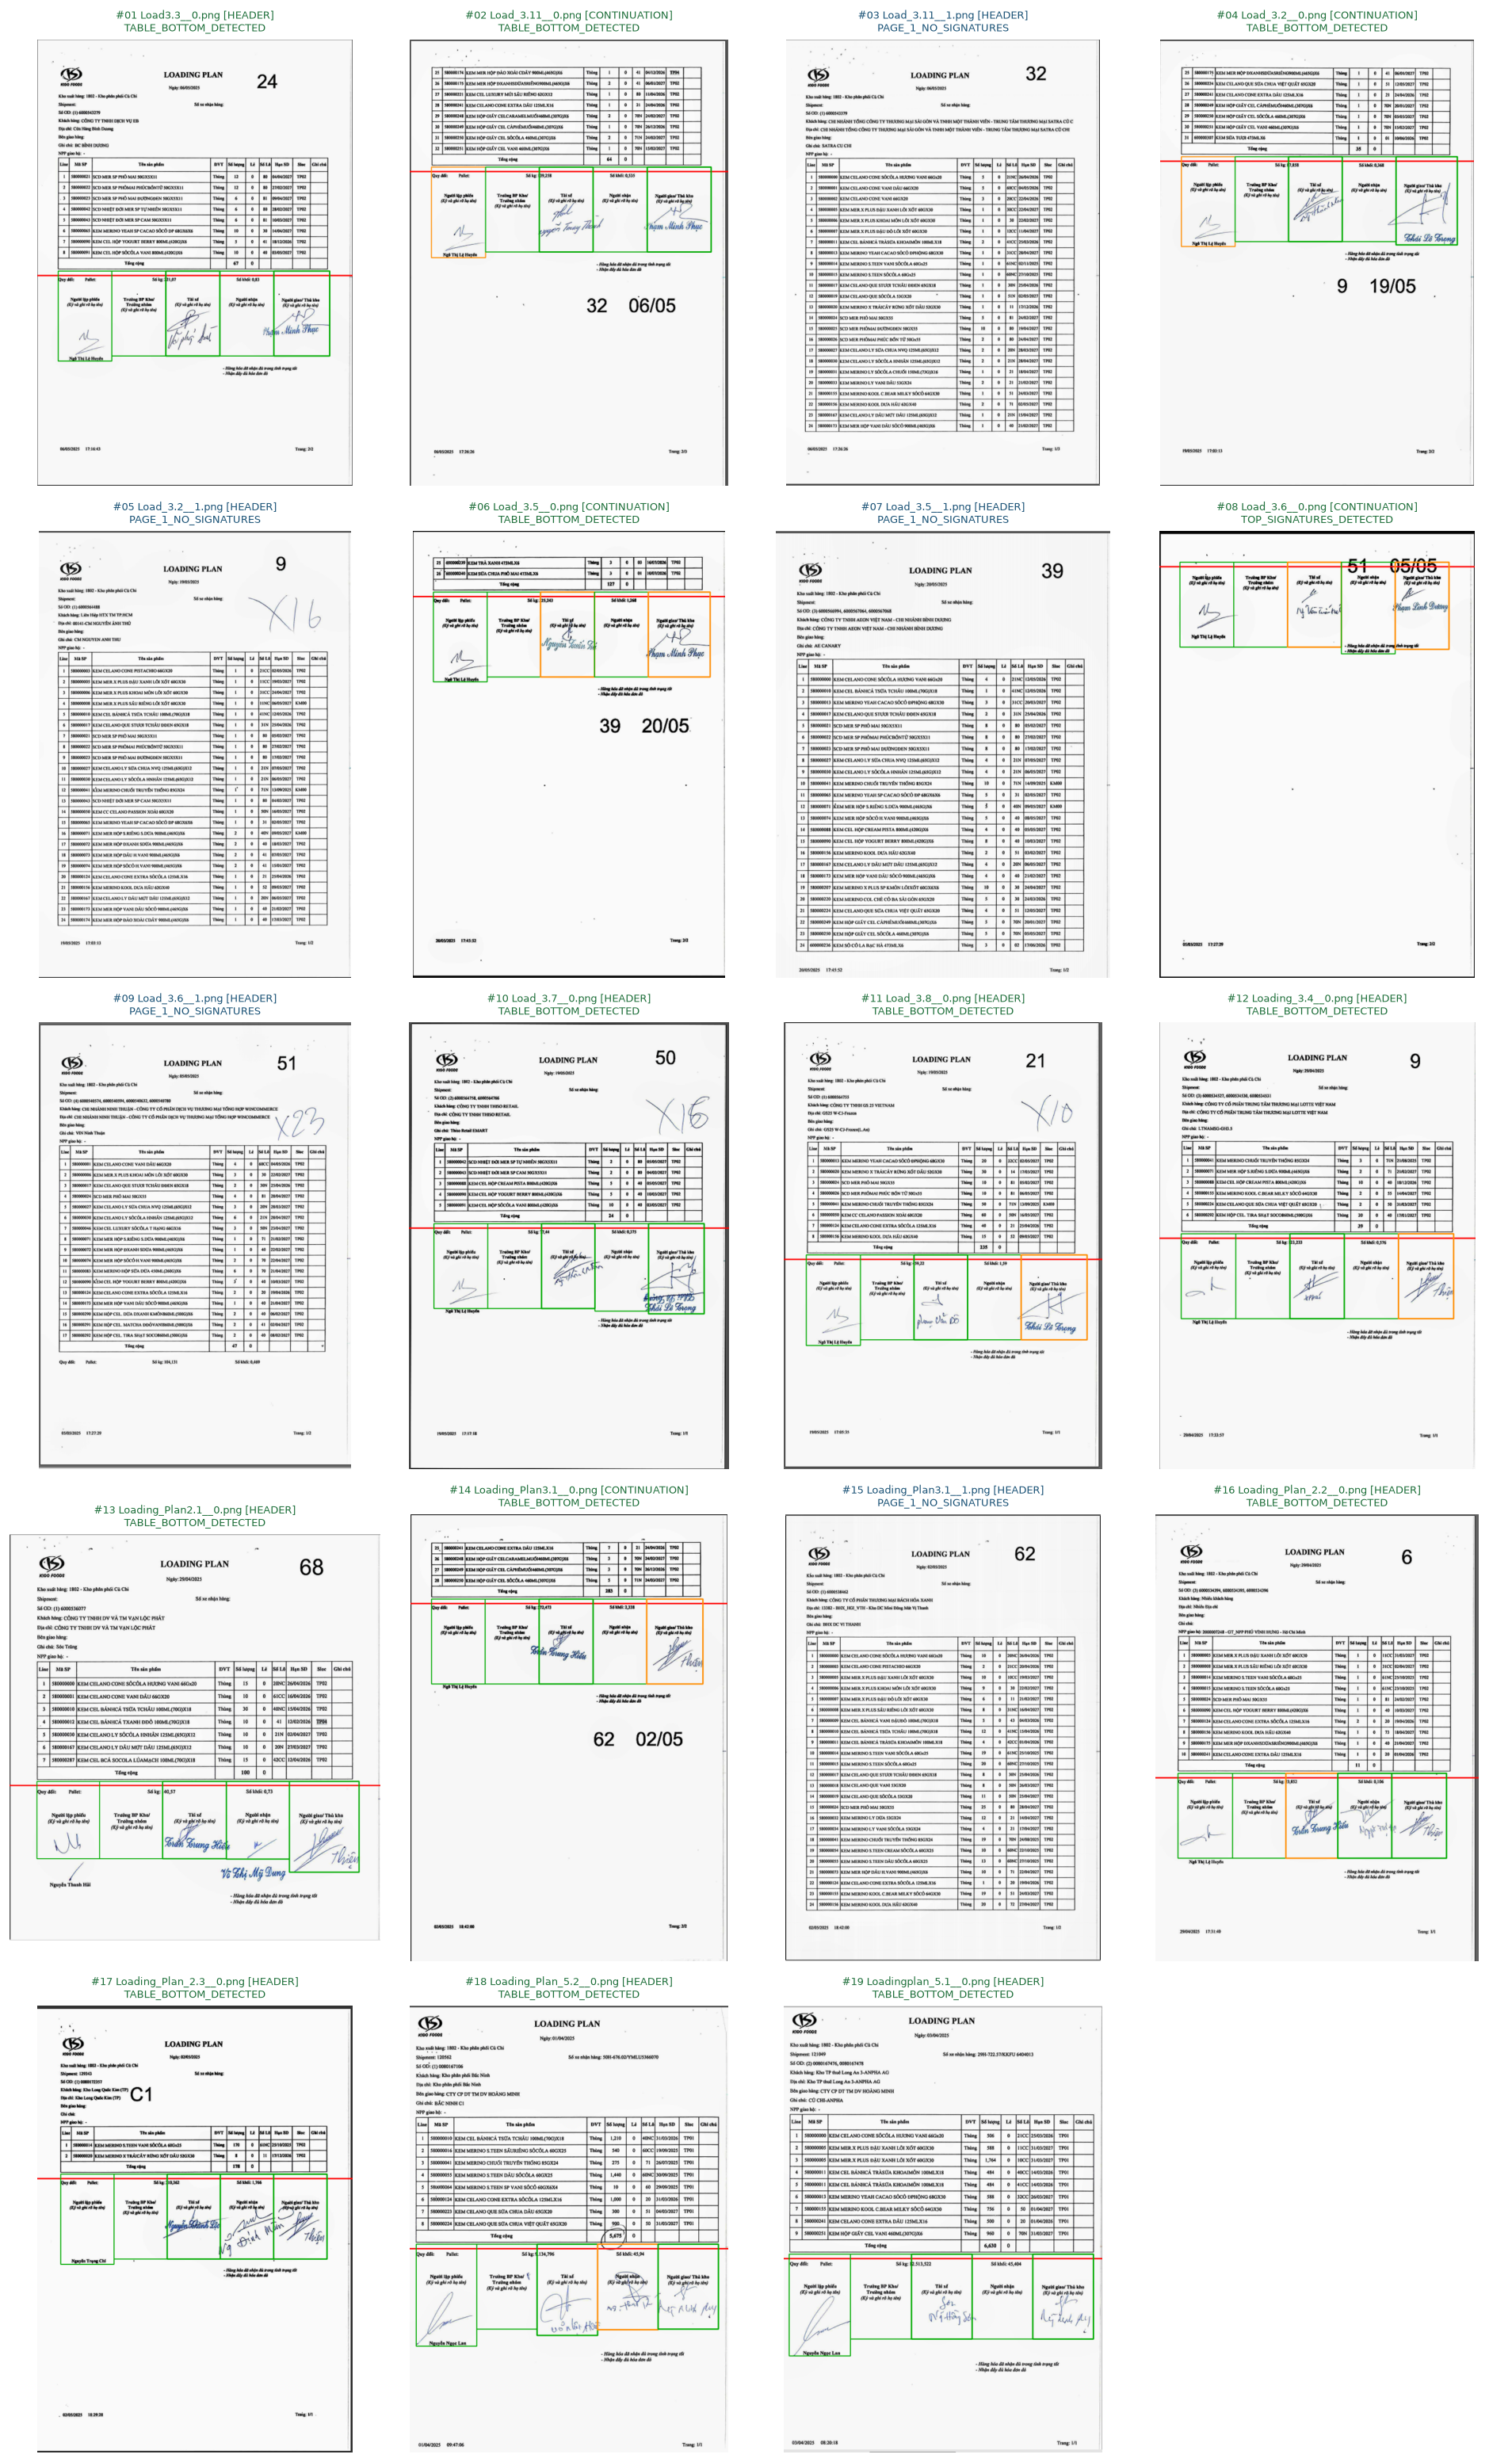

In [16]:
def draw_zone(img, zone, thick=3):
    out = img.copy()
    h, w = out.shape[:2]
    ay = zone.get("anchor_y")
    if ay is not None and zone.get("targets"):
        cv2.line(out, (0, int(ay * h)), (w, int(ay * h)), (0, 0, 255), max(1, thick - 1))
    for t in zone.get("targets") or []:
        y1, x1, y2, x2 = t["box_norm"]
        col = (0, 170, 0) if t.get("column_source") == "OCR_LABEL" else (0, 140, 255)
        cv2.rectangle(out, (int(x1 * w), int(y1 * h)), (int(x2 * w), int(y2 * h)), col,
                      thick if t["required"] else max(1, thick - 2))
    return out

n = len(pages)
ncol = 4
nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(16, 5.2 * nrow))
axes = np.array(axes).reshape(-1)
for i, p in enumerate(pages):
    ax = axes[i]
    ax.axis("off")
    if p["image"] is None:
        ax.set_title(f"{p['file_name']}\nLOI DOC ANH: {p['read_error']}", fontsize=8, color="red")
        continue
    vis = draw_zone(p["image"], p["zone"], thick=6)
    s = 900.0 / vis.shape[0]
    vis = cv2.resize(vis, (int(vis.shape[1] * s), 900), interpolation=cv2.INTER_AREA)
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    kind = lpp.page_kind(p)
    color = {"TARGETS": "#1e6f3a", "PAGE_1_NO_SIGNATURES": "#1a5276"}.get(kind, "#b03a2e")
    ax.set_title(f"#{i+1:02d} {p['file_name']} [{p['page_role']}]\n{p['zone'].get('status')}", fontsize=8, color=color)
for j in range(n, len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.show()

### B.4b Cận cảnh khối ký (chỉ các trang có target)

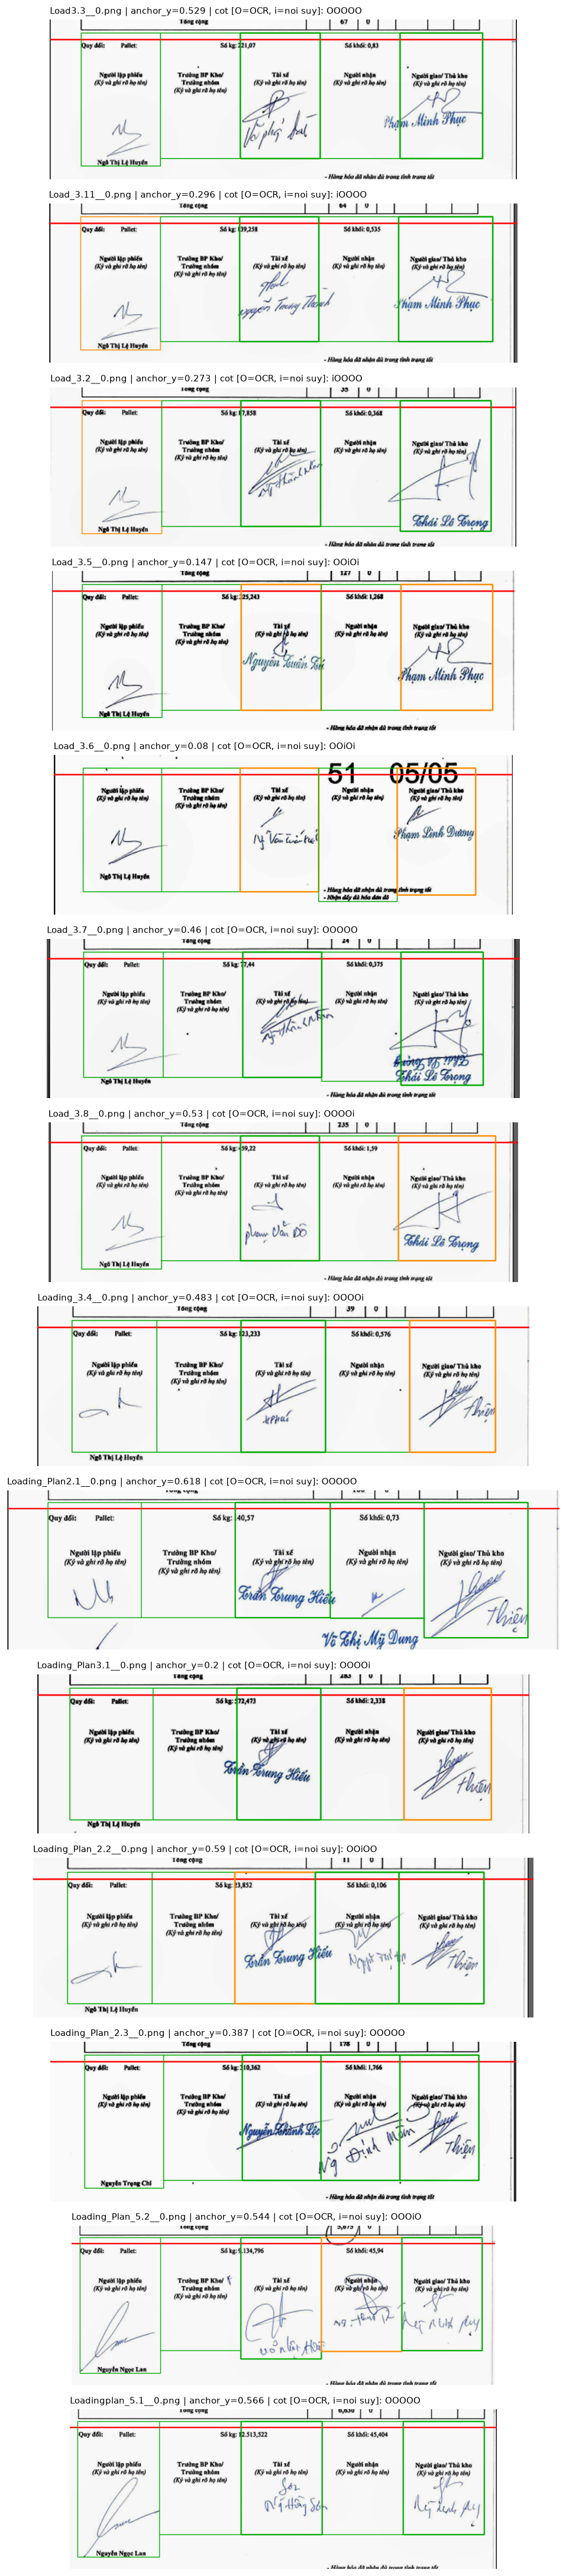

In [17]:
tpages = [p for p in pages if lpp.page_kind(p) == "TARGETS"]
fig, axes = plt.subplots(len(tpages), 1, figsize=(14, 2.6 * len(tpages)))
axes = np.atleast_1d(axes)
for ax, p in zip(axes, tpages):
    z = p["zone"]
    img = draw_zone(p["image"], z, thick=4)
    h = img.shape[0]
    ys = [t["box_norm"][0] for t in z["targets"]] + [t["box_norm"][2] for t in z["targets"]]
    y1, y2 = max(0, int((min(ys) - 0.02) * h)), min(h, int((max(ys) + 0.02) * h))
    crop = img[y1:y2]
    s = 1400.0 / crop.shape[1]
    crop = cv2.resize(crop, (1400, max(1, int(crop.shape[0] * s))), interpolation=cv2.INTER_AREA)
    ax.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
    ax.axis("off")
    src = "".join("O" if t.get("column_source") == "OCR_LABEL" else "i" for t in z["targets"])
    ax.set_title(f"{p['file_name']} | anchor_y={z['anchor_y']} | cot [O=OCR, i=noi suy]: {src}", fontsize=9, loc="left")
plt.tight_layout()
plt.show()

---
## B.5 Đối chiếu Ground Truth v4 — cấp trang và cấp khung

GT v4 (`output/stage4_dynamic_gt_v4/gt_labeled.json`) do người gán nhãn bằng mắt trên đúng ảnh production (xem AGENTS.md 9.10.D, 9.11.D). Cell này **so sống** kết quả zone vừa chạy với GT: loại trang và box từng target. Các nhãn phụ thuộc box (`frame_quality`, `sig_cut`) chỉ tính trên ô `box_changed = false` — vì chúng được gán trên box cũ.

In [18]:
gt = json.loads(GT_V4.read_text(encoding="utf-8"))
print(f"GT: {gt.get('dataset_name')}  v{gt.get('version')}  built_at={gt.get('built_at')}")
GT_STALE = gt.get("stage3b_resolver_md5") != RESOLVER_MD5 or gt.get("labels_config_md5") != LABELS_MD5
print(f"md5 resolver GT={gt.get('stage3b_resolver_md5')} | hien tai={RESOLVER_MD5}")
print(f"md5 config  GT={gt.get('labels_config_md5')} | hien tai={LABELS_MD5}")
print("=> GT LECH resolver/config hien tai: so doi chieu co the khong con dung" if GT_STALE
      else "=> GT sinh tren dung resolver + config hien tai")

# --- cap trang ---
live = {p["file_name"]: p for p in pages}
pg_rows = []
for gp in gt["pages"]:
    lp = live.get(gp["file_name"])
    lk = lpp.page_kind(lp) if lp else "KHONG_CO_TRONG_TAP_LIVE"
    pg_rows.append({"file": gp["file_name"], "gt_page_kind": gp["page_kind"], "live_page_kind": lk,
                    "gt_has_signature_block": gp.get("has_signature_block", "-"),
                    "khop": "KHOP" if lk == gp["page_kind"] else "LECH"})
df_pg = pd.DataFrame(pg_rows)
print(f"\nCap trang: {int((df_pg['khop'] == 'KHOP').sum())}/{len(df_pg)} trang cung page_kind voi GT")
lech = df_pg[df_pg["khop"] != "KHOP"]
if len(lech):
    display(lech)
nb_lbl = df_pg[df_pg["gt_has_signature_block"] != "-"]
print("Trang co nhan has_signature_block trong GT:", dict(Counter(zip(nb_lbl["live_page_kind"], nb_lbl["gt_has_signature_block"]))))

# --- cap khung ---
live_t = {}
for p in pages:
    for i, t in enumerate((p["zone"] or {}).get("targets") or []):
        live_t[lpp.target_id(p["file_name"], i)] = t
n_same = n_diff = n_missing = 0
diffs = []
for t in gt["targets"]:
    lt = live_t.get(t["target_id"])
    if lt is None:
        n_missing += 1
        continue
    d = max(abs(round(float(a), 3) - float(b)) for a, b in zip(lt["box_norm"], t["box_norm"]))
    if d <= 1e-6 and lt["role"] == t["role"]:
        n_same += 1
    else:
        n_diff += 1
        diffs.append((t["target_id"], t["box_norm"], lt["box_norm"]))
print(f"\nCap khung: GT {len(gt['targets'])} target | box trung {n_same} | lech {n_diff} | GT co ma live khong co {n_missing} "
      f"| live co ma GT khong co {len(set(live_t) - {t['target_id'] for t in gt['targets']})}")
for d in diffs[:10]:
    print("  LECH", d)

unchanged = [t for t in gt["targets"] if not t.get("box_changed")]
print(f"\nNhan phu thuoc box — chi tren {len(unchanged)} o box_changed=false:")
print("  frame_quality:", dict(Counter(t.get("frame_quality") for t in unchanged)))
print("  sig_cut      :", dict(Counter(t.get("sig_cut") for t in unchanged)))
print("  overflow     :", dict(Counter(t.get("overflow") for t in unchanged)))
print("Nhan chinh own_signature (moi o):", dict(Counter(t.get("own_signature") for t in gt["targets"])))

GT: KIDO LOADING_PLAN Dynamic Zone GT v4 — DUONG PRODUCTION, box per-column (Giai doan 4)  v4.0.0  built_at=2026-09-27T16:12:30
md5 resolver GT=7a6c49eca75b1d9a5ffff5d08ac54104 | hien tai=aa1f1e0833e0570c4deb14b1b6514d39
md5 config  GT=ada3e2f39ec96da89d462b6fae57cc68 | hien tai=ada3e2f39ec96da89d462b6fae57cc68
=> GT LECH resolver/config hien tai: so doi chieu co the khong con dung

Cap trang: 19/19 trang cung page_kind voi GT
Trang co nhan has_signature_block trong GT: {('PAGE_1_NO_SIGNATURES', 'NO'): 5, ('TARGETS', 'YES'): 1}

Cap khung: GT 70 target | box trung 70 | lech 0 | GT co ma live khong co 0 | live co ma GT khong co 0

Nhan phu thuoc box — chi tren 44 o box_changed=false:
  frame_quality: {'GOOD': 43, 'PARTIAL': 1}
  sig_cut      : {'NO': 30, 'YES': 14}
  overflow     : {'NONE': 27, 'FROM_RIGHT': 6, 'BOTH': 3, 'FROM_LEFT': 8}
Nhan chinh own_signature (moi o): {'YES': 44, 'NO': 25, 'AMBIGUOUS': 1}


---
## B.6 Kết quả Tầng 4 trên box Tầng 3b — ĐỌC TỪ ARTIFACT

Notebook này **không** chấm lại detector. Số dưới đây đọc từ `output/stage4_out/stage4_lp_prod_benchmark.json` (sinh bởi `tools/bench_lp_prod.py`). Cảnh báo bắt buộc đi kèm được **tính từ chính GT/benchmark**, in ngay sau bảng — phải đọc cùng nhau.

In [19]:
bench = json.loads(BENCH.read_text(encoding="utf-8"))
BENCH_STALE = bench.get("stage3b_resolver_mtime") != mtime(RESOLVER)
print(f"Benchmark: {bench.get('benchmark')}")
print(f"  GT={bench.get('gt_source')} v{bench.get('gt_version')} | nhan chinh={bench.get('primary_label')} "
      f"| cham {bench.get('n_scored')} o, loai AMBIGUOUS {bench.get('n_ambiguous_excluded')} {bench.get('ambiguous')}")
print(f"  v2_reproduces_manifest={bench.get('v2_reproduces_manifest')} | gt_coverage={bench.get('gt_coverage')}")
print(f"  resolver mtime luc bench={bench.get('stage3b_resolver_mtime')} | hien tai={mtime(RESOLVER)}"
      + ("  => BENCH CO THE LOI THOI" if BENCH_STALE else ""))

def mrow(name, m):
    return {"nhom": name, **{k: m.get(k) for k in ("n", "tp", "tn", "fp", "fn", "precision", "recall", "f1", "accuracy")}}

print("\n[Cap trang] page_level:", bench.get("page_level", {}).get("summary"))
display(pd.DataFrame(bench.get("page_level", {}).get("rows", [])))

rows = [mrow(f"overall {e}", bench["overall"][e]) for e in ("v1", "v2")]
for req, d in sorted(bench.get("by_required", {}).items()):
    rows += [mrow(f"required={req} {e}", d[e]) for e in ("v1", "v2")]
for fq, d in sorted(bench.get("by_frame_quality", {}).items()):
    rows += [mrow(f"frame_quality={fq} {e} (box_changed=false)", d[e]) for e in ("v1", "v2")]
display(pd.DataFrame(rows))

oo = bench.get("overflow_only", {})
print(f"\nO chi co muc tran tu cot ben (presence=PRESENT & own_signature=NO, box_changed=false): n={oo.get('n')} "
      f"| v1 bao co ky {oo.get('v1_detected')} | v2 bao co ky {oo.get('v2_detected')}")
for w in bench.get("warnings", []):
    print("WARNING (artifact):", w)

Benchmark: Tang 4 v1 vs ver2 tren DUONG PRODUCTION LOADING_PLAN (anh Tang 1 H=2200 + zone Tang 3b)
  GT=output/stage4_dynamic_gt_v4/gt_labeled.json v4.0.0 | nhan chinh=own_signature | cham 69 o, loai AMBIGUOUS 1 ['Loading_Plan_5.2__0__T01']
  v2_reproduces_manifest=True | gt_coverage=100.0
  resolver mtime luc bench=2026-09-27T17:49:37 | hien tai=2026-09-27T17:49:37

[Cap trang] page_level: {'CORRECT_NO_BLOCK': 5}

O chi co muc tran tu cot ben (presence=PRESENT & own_signature=NO, box_changed=false): n=9 | v1 bao co ky 9 | v2 bao co ky 0
WARNING (artifact): TN=0 (nhan CHINH own_signature) o engine v1: moi o chua ky (25) deu bi cham co ky — engine KHONG phan biet duoc o chua ky tren duong production


,file_name,page_kind,zone_status,has_signature_block,result
0,Load_3.11__1.png,PAGE_1_NO_SIGNATURES,PAGE_1_NO_SIGNATURES,NO,CORRECT_NO_BLOCK
1,Load_3.2__1.png,PAGE_1_NO_SIGNATURES,PAGE_1_NO_SIGNATURES,NO,CORRECT_NO_BLOCK
2,Load_3.5__1.png,PAGE_1_NO_SIGNATURES,PAGE_1_NO_SIGNATURES,NO,CORRECT_NO_BLOCK
3,Load_3.6__1.png,PAGE_1_NO_SIGNATURES,PAGE_1_NO_SIGNATURES,NO,CORRECT_NO_BLOCK
4,Loading_Plan3.1__1.png,PAGE_1_NO_SIGNATURES,PAGE_1_NO_SIGNATURES,NO,CORRECT_NO_BLOCK


,nhom,n,tp,tn,fp,fn,precision,recall,f1,accuracy
0,overall v1,69,44,0,25,0,63.77,100.0,77.88,63.77
1,overall v2,69,44,25,0,0,100.00,100.0,100.00,100.00
2,required=False v1,37,12,0,25,0,32.43,100.0,48.98,32.43
3,required=False v2,37,12,25,0,0,100.00,100.0,100.00,100.00
4,required=True v1,32,32,0,0,0,100.00,100.0,100.00,100.00
5,required=True v2,32,32,0,0,0,100.00,100.0,100.00,100.00
6,frame_quality=GOOD v1 (box_changed=false),42,25,0,17,0,59.52,100.0,74.63,59.52
7,frame_quality=GOOD v2 (box_changed=false),42,25,17,0,0,100.00,100.0,100.00,100.00
8,frame_quality=PARTIAL v1 (box_changed=false),1,1,0,0,0,100.00,100.0,100.00,100.00
9,frame_quality=PARTIAL v2 (box_changed=false),1,1,0,0,0,100.00,100.0,100.00,100.00


In [20]:
# CANH BAO BAT BUOC — tinh tu artifact, khong viet tay (AGENTS.md 9.11.D)
src_dist = gt.get("own_signature_source_distribution", {})
n_design = sum(v for k, v in src_dist.items() if k.startswith("gt_v3"))
n_holdout = sum(v for k, v in src_dist.items() if not k.startswith("gt_v3"))
n_pages_block = sum(1 for p in gt["pages"] if p["page_kind"] == "TARGETS")
modal = Counter(p["modality"] for p in pages if p["modality"])
print("CANH BAO — doc truoc khi trich dan so o bang tren:")
print(f" 1. Engine chu ky ver2 duoc thiet ke SAU KHI xem nhan GT v3: {n_design}/{len(gt['targets'])} o cua GT v4 "
      f"la tap thiet ke => P/R tren tap nay KHONG phai uoc luong tong quat hoa.")
print(f" 2. Holdout that chi {n_holdout} o (nguon: {[k for k in src_dist if not k.startswith('gt_v3')]}).")
print(f" 3. Mau so: {n_pages_block} trang co khoi ky, 1 bo bieu mau LOADING_PLAN.")
print(f" 4. Modality cac trang co target (do song): {dict(modal)} — nhanh BW chua duoc kiem chung; chu ky but den chua do.")
print(" 5. Engine ver2 chi dung cho zone dong Tang 3b (box chat); v1 giu cho hop tinh (AGENTS.md muc 8, 9.11.D).")
print(f" 6. Trang thai doi chieu: BOX_MATCH={BOX_MATCH} | GT_STALE={GT_STALE} | BENCH_STALE={BENCH_STALE}")

CANH BAO — doc truoc khi trich dan so o bang tren:
 1. Engine chu ky ver2 duoc thiet ke SAU KHI xem nhan GT v3: 65/70 o cua GT v4 la tap thiet ke => P/R tren tap nay KHONG phai uoc luong tong quat hoa.
 2. Holdout that chi 5 o (nguon: ['gt_load35.json (3 annotator mu, majority)']).
 3. Mau so: 14 trang co khoi ky, 1 bo bieu mau LOADING_PLAN.
 4. Modality cac trang co target (do song): {'TRUE_COLOR': 14} — nhanh BW chua duoc kiem chung; chu ky but den chua do.
 5. Engine ver2 chi dung cho zone dong Tang 3b (box chat); v1 giu cho hop tinh (AGENTS.md muc 8, 9.11.D).
 6. Trang thai doi chieu: BOX_MATCH=True | GT_STALE=True | BENCH_STALE=False


---
## B.7 `HOA_DON` — hoãn (không chạy detector)

Lý do: quy chuẩn ký nhận / đóng mộc trên hóa đơn và bố cục bảng **khác nhau theo từng chi nhánh / kênh** (siêu thị MT, NPP GT, …). Một template chung sẽ đặt sai ô ký cho một phần các kênh. Hướng đúng là tách template theo từng chi nhánh/kênh và gán nhãn GT riêng cho từng template — việc này **chưa làm**.

Contract hiện tại: E2E (`kido_pipeline`) đưa `HOA_DON` → `UNMAPPED` / ABSTAIN với `zone_status = HOA_DON_ZONE_DEFERRED`; manifest Tầng 4 ver2 ghi `HOA_DON` là ngoài phạm vi → `CHUA_CHUAN_HOA_VUNG_KY` / ABSTAIN. Cell dưới chỉ **đếm** số trang hóa đơn theo Tầng 2 và theo manifest ver2 — không chạy detector.

In [21]:
hd_s2 = sorted(fn for fn, r in s2_map.items() if r.get("doc_type") == "HOA_DON")
print(f"So trang HOA_DON theo Tang 2: {len(hd_s2)}")
man = lpp.load_manifest_v2()
hd_man = [d for d in man["documents"] if d.get("doc_type") == "HOA_DON"]
print(f"So trang HOA_DON trong manifest ver2: {len(hd_man)}")
print("  doc_status :", dict(Counter(d.get("doc_status") for d in hd_man)))
print("  zone_status:", dict(Counter(d.get("zone_status") for d in hd_man)))
print("  action     :", dict(Counter(d.get("action") for d in hd_man)))
n_with_targets = sum(1 for d in hd_man if d.get("targets"))
print(f"  trang HOA_DON co target duoc cham: {n_with_targets} (ky vong 0 khi hoan)")

So trang HOA_DON theo Tang 2: 21
So trang HOA_DON trong manifest ver2: 21
  doc_status : {'CHUA_CHUAN_HOA_VUNG_KY': 21}
  zone_status: {'CHUA_CHUAN_HOA_VUNG_KY': 21}
  action     : {'ABSTAIN': 21}
  trang HOA_DON co target duoc cham: 0 (ky vong 0 khi hoan)


---
## B.8 Giới hạn đã biết & việc tiếp theo

- **Chữ ký vắt qua ranh giới cột** vẫn bị cắt ở một phần ô: ranh giới giữa các cột giữ nguyên để không vi phạm luật “cột không chồng lấn”. Số ô cụ thể: xem AGENTS.md 9.11.B (đếm bằng mắt, không có artifact JSON riêng).
- **Nhánh BW và chữ ký bút đen** của Tầng 4 ver2 chưa được kiểm chứng trên zone động (xem cảnh báo mục B.6).
- **Hai nguồn sự thật** cho `LOADING_PLAN`: preset tĩnh 3 vai trò (`SIGNATURE_PRESET_MAP`) và zone động 5 vai trò — chưa thống nhất.
- **Gộp phán quyết hồ sơ đa trang**: đã làm ở Tầng 4 ver2 (`dossier_verdicts`, AGENTS.md 9.12.A), nhóm trang lấy từ manifest Tầng 3 — xem bảng A.10.
- **`HOA_DON`**: tách template theo chi nhánh/kênh + GT riêng (mục B.7).
- `required` theo kênh (`Người lập phiếu` / `Người nhận hàng`): đã chốt trong `config/stage4_lp_required_policy.json` (AGENTS.md 9.12.A), áp ở Tầng 4 — không thuộc Tầng 3b.

Công cụ đo trên **ảnh raw ~850px** (`bench_lp_dynamic.py`, `bench_lp_new_gt.py`, `bench_lp_zone_ab.py`, `ab_v2_signature_fix.py`, `build_lp_dynamic_crops.py`, `merge_lp_dynamic_labels.py`, `report_lp_dynamic.py`) là **lịch sử**, không phản ánh production. Đường đo hiện hành: `tools/lp_production_path.py` → `tools/bench_lp_prod.py`.